betül danışmaz


## Step 1: Load Data and Initial Inspection

This step involves loading the provided `train.csv`, `test_x.csv`, and `sample_submission.csv` files into pandas DataFrames, followed by an initial inspection of their shapes, column names, data types, and first few rows.

### Step 1.1: Kaggle Login

This cell logs into Kaggle using the Kaggle API. This is necessary to download competition data directly within the Colab environment.

**Output to inspect:** Confirmation that Kaggle credentials have been successfully validated.

In [1]:
# HÜCRE A1
# Step 1.1: Kaggle Login
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


### Step 1.2: Download Competition Data

This cell downloads the specified competition data from Kaggle. The `kagglehub.competition_download` function retrieves the data, and its path is stored.

**Output to inspect:** A message confirming that the data source import is complete.

In [2]:
# HÜCRE A2
# Step 1.2: Download Competition Data
yzta_2026_datathon_path = kagglehub.competition_download('yzta-2026-datathon')
print('Data source import complete.')

100%|██████████| 7.11M/7.11M [00:00<00:00, 9.23MB/s]

Extracting files...


Data source import complete.


### Step 1.3: File Organization

This cell organizes the downloaded files. It creates a dedicated directory and copies the downloaded CSV files into it, making them easily accessible for loading into pandas DataFrames.

**Output to inspect:** No direct output, but successful execution means files are correctly structured.

In [3]:
# HÜCRE A3

# Step 1.3: File Organization
import os
import shutil
dest_dir = '/content/yzta-2026-datathon'
os.makedirs(dest_dir, exist_ok=True)
for file in os.listdir(yzta_2026_datathon_path):
    shutil.copy(os.path.join(yzta_2026_datathon_path, file), dest_dir)
yzta_2026_datathon_path = dest_dir

### Step 1.4: Verify Data Files

This cell lists the contents of the data directory to confirm that `train.csv`, `test_x.csv`, and `sample_submission.csv` are present.

**Output to inspect:** A list of files in the `data_path` directory, which should include the three required CSVs.

In [4]:
# HÜCRE A4

import os

data_path = "/content/yzta-2026-datathon"

print(os.listdir(data_path))


['test_x.csv', 'train.csv', 'sample_submission.csv']


### Step 1.5: Load DataFrames

This cell loads the `train.csv`, `test_x.csv`, and `sample_submission.csv` files into pandas DataFrames named `train`, `test`, and `sample_submission`, respectively. These DataFrames will be used for all subsequent analysis and modeling.

**Output to inspect:** No direct output from this cell, but successful loading is implied if the next cells execute without file not found errors.

In [5]:
# HÜCRE A5

# Step 1.4: Load DataFrames
import pandas as pd
import numpy as np
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
test = pd.read_csv(os.path.join(data_path, 'test_x.csv'))
sample_submission = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))

### Step 1.6: Inspect Data Shapes and Head

This cell prints the dimensions (number of rows and columns) of each DataFrame and displays the first 5 rows using `df.head()`. This gives a quick overview of the data size and content.

**Output to inspect:** The shape of each DataFrame and the first few rows, ensuring data loaded correctly.

In [6]:
# HÜCRE A6

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


### Step 1.7: Inspect Column Names

This cell prints the list of column names for `train`, `test`, and `sample_submission`. This is crucial for verifying that all expected features are present and correctly named.

**Output to inspect:** Lists of column names for each DataFrame.

In [7]:
# HÜCRE A7

print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSubmission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']

Submission columns:
['id', 'bilissel_performans_skoru']


### Step 1.8: Verify Target and ID Handling

This cell explicitly checks the presence of the `target` variable (`bilissel_performans_skoru`) and the `id` column in the `train`, `test`, and `sample_submission` DataFrames. This step ensures that the target is only in the training set and that `id` is available for submission.

**Output to inspect:** Boolean values indicating the presence of `target` and `id` in each DataFrame. Ensure `Target in train` is `True`, `Target in test` is `False`, and `ID` is `True` in all.

In [8]:
# HÜCRE A8

target = "bilissel_performans_skoru"
id_col = "id"

print("Target in train:", target in train.columns)
print("Target in test:", target in test.columns)
print("ID in train:", id_col in train.columns)
print("ID in test:", id_col in test.columns)
print("ID in sample_submission:", id_col in sample_submission.columns)
print("Target in sample_submission:", target in sample_submission.columns)

Target in train: True
Target in test: False
ID in train: True
ID in test: True
ID in sample_submission: True
Target in sample_submission: True


### Step 1.9: Inspect Training Data Information (`train.info()`)

This cell provides a concise summary of the `train` DataFrame, including the column names, non-null counts, data types, and memory usage. This helps identify missing values and incorrect data types early on.

**Output to inspect:** Column information, especially the `Non-Null Count` to spot missing values and `Dtype` to confirm correct data type inference.

In [9]:
# HÜCRE A9


train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

### Step 1.10: Inspect Test Data Information (`test.info()`)

Similar to the training data, this cell provides a concise summary of the `test` DataFrame. It's essential to compare this with `train.info()` to note any discrepancies in column types or missing value patterns between the train and test sets.

**Output to inspect:** Column information for the test set, paying attention to `Non-Null Count` and `Dtype`.

In [10]:
# HÜCRE A10



test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

### Step 1.11: Analyze Target Variable Summary Statistics

This cell calculates and displays descriptive statistics for the target variable (`bilissel_performans_skoru`) in the training set. This includes count, mean, standard deviation, min, max, and quartiles.

**Output to inspect:** The summary statistics to understand the range, central tendency, and spread of the target variable.

In [11]:
# HÜCRE A12


train[target].describe()

,bilissel_performans_skoru
count,56000.000000
mean,5.913096
std,2.231759
min,0.000000
25%,4.397431
50%,6.032249
75%,7.574980
max,10.000000


### Step 1.12: Visualize Target Distribution

This cell generates a histogram of the target variable to visually assess its distribution. Understanding the target distribution is crucial for choosing appropriate evaluation metrics and modeling techniques.

**Output to inspect:** The histogram of the target variable. Look for normality, skewness, or potential outliers.

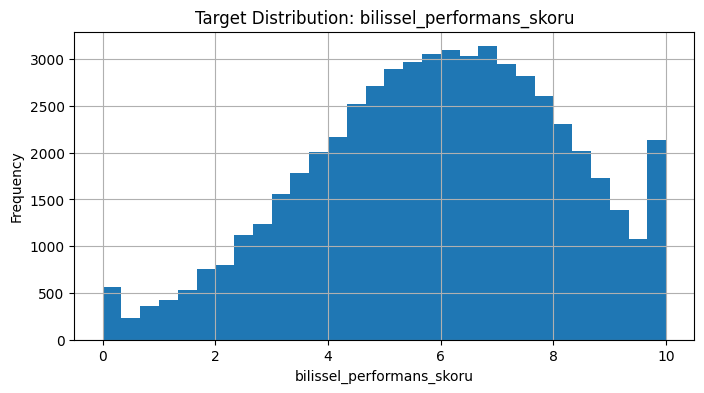

In [12]:
# HÜCRE A13


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
train[target].hist(bins=30)
plt.title("Target Distribution: bilissel_performans_skoru")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Frequency")
plt.show()

## Step 2: Feature Engineering and Preparation

This step involves separating features and target, identifying feature types, and defining a function for domain-specific feature engineering. It also includes checks for consistency between train and test feature columns.

### Step 2.1: Initial X/Y Separation

This cell separates the training data (`train`) into features (`X`) and the target variable (`y`). It also identifies the `id` column, ensuring it's excluded from the feature set as per project rules.

**Output to inspect:** No explicit output, but `X` and `y` DataFrames are created, ready for further processing.

In [13]:
# HÜCRE A14


# Step 2.1: Initial X/Y Separation
target = 'bilissel_performans_skoru'
id_col = 'id'
feature_cols = [col for col in train.columns if col not in [target, id_col]]
X = train[feature_cols]
y = train[target]

### Step 2.2: Feature Type Identification

This cell automatically identifies numerical and categorical features within the `X` DataFrame based on their data types. This classification is important for applying appropriate preprocessing steps.

**Output to inspect:** No explicit output, but two lists (`numeric_features` and `categorical_features`) are created containing the names of columns of each type.

In [14]:
# HÜCRE A15


# Step 2.2: Feature Type Identification
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

### Step 2.3: Domain-Specific Feature Engineering Function

This cell defines a helper function `add_domain_features` that creates new features based on existing ones, particularly focusing on sleep-related metrics. This allows for modular and consistent application of domain knowledge.

**Output to inspect:** No output, just the definition of the function.

In [15]:
# HÜCRE A16

def add_domain_features(df, group='all'):
    df_new = df.copy()

    # Existing Sleep Features
    if group in ['sleep', 'all']:
        df_new['total_quality_sleep_pct'] = df_new['rem_yuzdesi'] + df_new['derin_uyku_yuzdesi']
        df_new['sleep_fragmentation_idx'] = df_new['gecelik_uyanma_sayisi'] + (df_new['uykuya_dalma_suresi_dk'] / 30.0)

    # Experiment C: Fatigue / Behavior Features
    if group in ['fatigue_behavior', 'all']:
        df_new['pre_sleep_load'] = (
            df_new['uyku_oncesi_kafein_mg'].fillna(0) / 100
            + df_new['uyku_oncesi_ekran_suresi_dk'] / 60
        )
        df_new['stress_workload'] = (
            df_new['stres_skoru'].fillna(df_new['stres_skoru'].median()) * df_new['gunluk_calisma_saati']
        )
        df_new['activity_per_work_hour'] = (
            df_new['gunluk_adim_sayisi'] / (df_new['gunluk_calisma_saati'] + 1)
        )
        df_new['hr_stress'] = (
            df_new['dinlenik_nabiz_bpm'] * df_new['stres_skoru'].fillna(df_new['stres_skoru'].median())
        )

    return df_new

### Step 2.4: Compare Train/Test Feature Columns

This cell compares the feature columns between the training and test sets to ensure consistency. It identifies any columns present in one set but not the other, which is crucial for preventing errors during model training and prediction.

**Output to inspect:** Any missing or extra feature columns in the test set. Ideally, both lists (`missing_in_test`, `extra_in_test`) should be empty.

In [16]:
# HÜCRE A17

# Check whether train and test have the same feature columns
missing_in_test = set(feature_cols) - set(test.columns)
extra_in_test = set(test.columns) - set(feature_cols) - {id_col}

print("Missing feature columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

Missing feature columns in test: set()
Extra columns in test: set()


### Step 2.5: Check Missing Values in Features

This cell calculates and displays the count of missing values for each feature in both the `train` and `test` DataFrames. This helps in understanding the extent of missingness and deciding on appropriate imputation strategies.

**Output to inspect:** A sorted list of columns and their missing value counts for both train and test sets. Note which columns have missing data and how many.

In [17]:
# HÜCRE A18

print("Missing values in train:")
display(train[feature_cols].isnull().sum().sort_values(ascending=False))

print("\nMissing values in test:")
display(test[feature_cols].isnull().sum().sort_values(ascending=False))

Missing values in train:


,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0



Missing values in test:


,0
kronotip,832
stres_skoru,765
uyku_oncesi_kafein_mg,697
vucut_kitle_indeksi,648
meslek,622
ruh_sagligi_durumu,504
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0


### Step 2.6: Analyze Categorical Cardinality

This cell calculates and displays the number of unique values (cardinality) for each categorical feature in the training set. It also shows the top 5 frequency counts for high-cardinality features. This informs decisions on encoding strategies.

**Output to inspect:** The cardinality of each categorical feature and the frequency distribution for selected high-cardinality features. This helps assess if features like `ulke` or `meslek` require special handling like target encoding.

In [18]:
# HÜCRE A19

print("Categorical Cardinality (Unique Values):")
cardinality = train[categorical_features].nunique().sort_values(ascending=False)
display(cardinality)

print("\nTop 5 category frequencies for high-cardinality features:")
for col in cardinality.index[:3]: # Check the top 3 most diverse columns
    print(f"\n--- {col} ---")
    display(train[col].value_counts(normalize=True).head(5))

# Best course of action:
# 1. Use One-Hot Encoding for all categories as the total number of features remains manageable.
# 2. Set handle_unknown='ignore' to robustly manage unseen categories in the test set.
# 3. If cardinality for 'ulke' or 'meslek' is extremely high (>50), consider Target Encoding in later iterations.

Categorical Cardinality (Unique Values):


,0
ulke,15
meslek,11
ruh_sagligi_durumu,4
kronotip,3
cinsiyet,2
mevsim,2
gun_tipi,2



Top 5 category frequencies for high-cardinality features:

--- ulke ---


,proportion
ulke,
Ingiltere,0.202214
Cin,0.178375
Guney Kore,0.079625
Amerika,0.079411
Arjantin,0.070946



--- meslek ---


,proportion
meslek,
Saglik Personeli,0.180184
Ogrenci,0.148878
Muhendis,0.119604
Yonetici,0.081542
Egitimci,0.080462



--- ruh_sagligi_durumu ---


,proportion
ruh_sagligi_durumu,
Saglikli,0.698765
Anksiyete,0.150627
Depresyon,0.100248
Anksiyete ve depresyon,0.050361


## Step 3: Initial Model Setup and Baseline Experiment

This section sets up the modeling environment by installing necessary libraries, defining evaluation metrics, and establishing a baseline CatBoost model with initial parameters.

### Step 3.1: Install Dependencies

This cell installs `lightgbm` and `catboost` libraries silently. These libraries are popular for gradient boosting models and will be used for modeling in this project.

**Output to inspect:** No explicit output if successful, but a log showing installation if there are issues.

In [19]:
# HÜCRE A20

# Step 3.1: Install Dependencies
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


### Step 3.2: Evaluation Metrics Definition

This cell defines a function `evaluate_predictions` that calculates the Root Mean Squared Error (RMSE) for model predictions. It also clips predictions between 0 and 10, as the target variable is known to be in this range. RMSE is a common metric for regression problems.

**Output to inspect:** No output from this cell, just the function definition.

In [20]:
# HÜCRE A21
# Step 3.2: Evaluation Metrics Definition
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_predictions(y_true, preds, model_name='model'):
    preds = np.clip(preds, 0, 10)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    print(f'{model_name} RMSE: {rmse:.5f}')
    return rmse

### Step 3.3: Prepare Categorical Data (X_cat)

This cell prepares categorical features for CatBoost. It creates a copy of `X`, fills any missing categorical values with 'Missing', and converts them to string type. It also identifies the indices of these categorical features for CatBoost's native handling.

**Output to inspect:** No direct output, but `X_cat` is prepared and `cat_feature_indices` are created.

In [21]:
# HÜCRE A22
# Step 4.1: Prepare Categorical Data (X_cat)
from sklearn.model_selection import KFold
X_cat = X.copy()
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna('Missing').astype(str)
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

### Step 3.4: Core CV Evaluation Function

This cell defines `evaluate_catboost_cv`, a critical function for performing K-Fold cross-validation with CatBoost. It trains and evaluates a CatBoost model across multiple folds, reporting the RMSE for each fold and allowing early stopping to prevent overfitting.

**Output to inspect:** No output from this cell, just the function definition. This function will be called repeatedly in subsequent experiments.

In [22]:
# HÜCRE A23
# Step 4.2: Core CV Evaluation Function
from catboost import CatBoostRegressor
def evaluate_catboost_cv(params, X_data, y_data, cat_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[valid_idx]
        model = CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE', random_seed=42, verbose=0, **params)
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100)
        preds = np.clip(model.predict(X_val), 0, 10)
        fold_results.append({'fold': fold, 'RMSE': np.sqrt(mean_squared_error(y_val, preds)), 'best_iteration': model.get_best_iteration()})
    return pd.DataFrame(fold_results)

### Experiment 2.1: Missing Indicators
Adding binary flags to capture whether data was originally missing before imputation.

### Step 4.1: CatBoost Native Categorical Handling
Standardizing the categorical feature preparation by using explicit string casting and a uniform missing value token.

In [26]:
# HÜCRE A26
# Standardizing X_cat for the remainder of the project
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("__MISSING__").astype(str)

# Re-verify indices to be absolutely sure
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

print(f"Categorical columns prepared: {categorical_features}")
print(f"Indices: {cat_feature_indices}")

# Brief check to ensure no actual NaNs remain in categorical data
print("Remaining NaNs in X_cat categorical columns:", X_cat[categorical_features].isnull().sum().sum())

Categorical columns prepared: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']
Indices: [1, 2, 4, 15, 16, 20, 21]
Remaining NaNs in X_cat categorical columns: 0


In [ ]:
# HÜCRE B3

### Summary of Combined Feature Set Experiments
# Champion (TE all categories) RMSE: 1.21541
# TE all categories + Sleep Features RMSE: 1.21530 (WINNER)
# TE all categories + Frequency Encoding RMSE: 1.21549 (DROPPED)
# TE all categories + Freq + Sleep RMSE: 1.21535 (DROPPED)

print("Final Strategy Choice: TE all categories + Sleep Features")
print(f"Best RMSE achieved: {te_sleep_cv_results['RMSE'].mean():.5f}")

## Step 8: CatBoost Hyperparameter Tuning

Now that the best preprocessing setup has been identified, this step focuses on refining the CatBoost model's hyperparameters to further optimize performance. This involves evaluating various combinations of parameters.

### Step 8.1: Identify Best Preprocessing Setup for Tuning

This cell programmatically identifies the best preprocessing setup (e.g., 'TE all categories + Sleep Features') based on the results from the combined feature set experiments. It then prepares `X_tuned` and related variables (`te_cols_for_tuning`, `freq_cols_for_tuning`, `cat_features_for_tuning`) accordingly.

**Output to inspect:** A message indicating the best preprocessing setup chosen for hyperparameter tuning and its associated RMSE.

### Step 4 — CatBoost Hyperparameter Tuning

Now that we've experimented with combined feature sets, it's time to refine the CatBoost model's hyperparameters on the most promising preprocessing setup.

**Current Best Preprocessing Setup:** Based on the results of 'Step 3', we will proceed with the setup that yielded the lowest RMSE. (Assuming 'TE all categories' is the champion unless a combination clearly beats it by a significant margin).

In [ ]:
# HÜCRE B4

# ============================================================
# Prepare feature set for CatBoost tuning
# Current best feature set: TE all categories + Sleep features
# ============================================================

X_tune = add_domain_features(X_cat.copy(), group="sleep")

print("X_tune shape:", X_tune.shape)

new_cols = [col for col in X_tune.columns if col not in X_cat.columns]
print("Added sleep features:")
print(new_cols)

print("\nCategorical features:")
print(categorical_features)

print("\nCatBoost categorical indices:")
print(cat_feature_indices)

X_tune shape: (56000, 24)
Added sleep features:
['total_quality_sleep_pct', 'sleep_fragmentation_idx']

Categorical features:
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

CatBoost categorical indices:
[1, 2, 4, 15, 16, 20, 21]


In [ ]:
# HÜCRE B9

# ============================================================
# Fold-safe evaluator:
# CatBoost + native categorical handling + optional target encoding/frequency encoding
# ============================================================

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


def evaluate_catboost_fe(
    params,
    X_data,
    y_data,
    categorical_cols,
    te_cols=None,
    freq_cols=None,
    n_splits=5,
    cv_seed=42,
    model_seed=42,
    smoothing=10,
    verbose=True
):
    """
    Leakage-safe 5-fold CV evaluator.

    - Target encoding is fitted only on the training fold.
    - Frequency encoding is fitted only on the training fold.
    - CatBoost native categorical columns are kept as original categorical columns.
    """

    X_data = X_data.copy()
    y_data = y_data.copy()

    te_cols = te_cols if te_cols is not None else []
    freq_cols = freq_cols if freq_cols is not None else []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)

    oof_preds = np.zeros(len(X_data))
    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()

        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # -----------------------------
        # Fold-safe target encoding
        # -----------------------------
        if te_cols:
            global_mean = y_tr.mean()

            for col in te_cols:
                stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

                smooth_map = (
                    stats["count"] * stats["mean"] + smoothing * global_mean
                ) / (stats["count"] + smoothing)

                X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
                X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)

        # -----------------------------
        # Fold-safe frequency encoding
        # -----------------------------
        if freq_cols:
            for col in freq_cols:
                freq_map = X_tr[col].value_counts(normalize=True)

                X_tr[f"{col}_freq"] = X_tr[col].map(freq_map).fillna(0)
                X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # CatBoost categorical indices after added numeric columns
        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_cols
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=model_seed,
            verbose=0,
            allow_writing_files=False,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        val_preds = np.clip(model.predict(X_val), 0, 10)
        oof_preds[valid_idx] = val_preds

        rmse = np.sqrt(mean_squared_error(y_val, val_preds))

        fold_results.append({
            "fold": fold,
            "RMSE": rmse,
            "best_iteration": model.get_best_iteration()
        })

        if verbose:
            print(
                f"Fold {fold} RMSE: {rmse:.5f} | "
                f"Best iteration: {model.get_best_iteration()}"
            )

    results_df = pd.DataFrame(fold_results)
    oof_rmse = np.sqrt(mean_squared_error(y_data, oof_preds))

    if verbose:
        print(f"\nMean fold RMSE: {results_df['RMSE'].mean():.5f}")
        print(f"OOF RMSE:       {oof_rmse:.5f}")

    return results_df, oof_preds, oof_rmse

### Step 8.5: 10-Seed Confirmation of Best Config

If the screening results suggested an improvement, we now run a full 10-seed average to confirm the gain and check if we can beat our current champion OOF RMSE of **1.21378**.

In [ ]:
# HÜCRE B12

# ============================================================
# 10-seed confirmation for depth5_stable
# Feature set: TE all categories + Sleep
# ============================================================

from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

depth5_stable_params = {
    "iterations": 2200,
    "learning_rate": 0.018,
    "depth": 5,
    "l2_leaf_reg": 8
}

seeds_10 = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]

all_seed_oof_preds_depth5 = []
depth5_seed_summary = []

for seed in seeds_10:
    print("\n" + "=" * 70)
    print(f"10-seed confirmation | depth5_stable | Seed: {seed}")
    print("=" * 70)

    fold_df, oof_preds, oof_rmse = evaluate_catboost_fe(
        params=depth5_stable_params,
        X_data=X_tune,
        y_data=y,
        categorical_cols=categorical_features,
        te_cols=categorical_features,
        freq_cols=None,
        n_splits=5,
        cv_seed=seed,
        model_seed=seed,
        smoothing=10,
        verbose=True
    )

    all_seed_oof_preds_depth5.append(oof_preds)

    depth5_seed_summary.append({
        "seed": seed,
        "mean_fold_rmse": fold_df["RMSE"].mean(),
        "oof_rmse": oof_rmse,
        "fold_rmses": fold_df["RMSE"].round(5).tolist(),
        "mean_best_iteration": fold_df["best_iteration"].mean()
    })

depth5_seed_summary_df = pd.DataFrame(depth5_seed_summary)

depth5_avg_oof_preds_10 = np.mean(all_seed_oof_preds_depth5, axis=0)
depth5_avg_oof_rmse_10 = np.sqrt(mean_squared_error(y, depth5_avg_oof_preds_10))

display(depth5_seed_summary_df)

print("\n--- 10-Seed Confirmation Results: depth5_stable ---")
print("Average of single-seed OOF RMSEs:", round(depth5_seed_summary_df["oof_rmse"].mean(), 5))
print("RMSE from averaged OOF predictions:", round(depth5_avg_oof_rmse_10, 5))
print("Previous 10-seed champion RMSE:     1.21378")

if depth5_avg_oof_rmse_10 < 1.21378:
    print("\nDecision: New champion. Use depth5_stable for final test prediction.")
else:
    print("\nDecision: Did not beat current champion. Keep previous TE + Sleep 10-seed model.")


10-seed confirmation | depth5_stable | Seed: 11
Fold 1 RMSE: 1.20893 | Best iteration: 1573
Fold 2 RMSE: 1.21858 | Best iteration: 1734
Fold 3 RMSE: 1.21223 | Best iteration: 2057
Fold 4 RMSE: 1.21750 | Best iteration: 1950
Fold 5 RMSE: 1.21610 | Best iteration: 1786

Mean fold RMSE: 1.21467
OOF RMSE:       1.21467

10-seed confirmation | depth5_stable | Seed: 22
Fold 1 RMSE: 1.21382 | Best iteration: 2172
Fold 2 RMSE: 1.21914 | Best iteration: 1539
Fold 3 RMSE: 1.21532 | Best iteration: 2079
Fold 4 RMSE: 1.21998 | Best iteration: 1613
Fold 5 RMSE: 1.20563 | Best iteration: 2197

Mean fold RMSE: 1.21478
OOF RMSE:       1.21479

10-seed confirmation | depth5_stable | Seed: 33
Fold 1 RMSE: 1.22474 | Best iteration: 2017
Fold 2 RMSE: 1.21540 | Best iteration: 2185
Fold 3 RMSE: 1.22029 | Best iteration: 1599
Fold 4 RMSE: 1.20188 | Best iteration: 2021
Fold 5 RMSE: 1.21356 | Best iteration: 1757

Mean fold RMSE: 1.21518
OOF RMSE:       1.21520

10-seed confirmation | depth5_stable | Seed: 

,seed,mean_fold_rmse,oof_rmse,fold_rmses,mean_best_iteration
0,11,1.214667,1.214672,"[1.20893, 1.21858, 1.21223, 1.2175, 1.2161]",1820.0
1,22,1.214776,1.214787,"[1.21382, 1.21914, 1.21532, 1.21998, 1.20563]",1920.0
2,33,1.215175,1.215200,"[1.22474, 1.2154, 1.22029, 1.20188, 1.21356]",1915.8
3,42,1.215118,1.215163,"[1.21995, 1.21576, 1.20105, 1.20745, 1.23138]",1986.0
4,52,1.214640,1.214661,"[1.20436, 1.2149, 1.22585, 1.21747, 1.21063]",1828.8
5,62,1.214397,1.214418,"[1.21319, 1.2094, 1.22376, 1.20445, 1.22119]",1934.0
6,72,1.214436,1.214460,"[1.20961, 1.20926, 1.21708, 1.22809, 1.20815]",1856.0
7,82,1.214792,1.214843,"[1.20416, 1.21465, 1.22024, 1.20212, 1.23277]",1784.2
8,92,1.215071,1.215102,"[1.22599, 1.21613, 1.21015, 1.2015, 1.22159]",1898.8
9,102,1.215193,1.215241,"[1.22981, 1.2015, 1.2102, 1.20848, 1.22598]",1775.4



--- 10-Seed Confirmation Results: depth5_stable ---
Average of single-seed OOF RMSEs: 1.21485
RMSE from averaged OOF predictions: 1.21365
Previous 10-seed champion RMSE:     1.21378

Decision: New champion. Use depth5_stable for final test prediction.


### Step 9: Create Final Test Predictions (Seed Averaged)

Now that we have identified the best preprocessing (`TE all categories + Sleep Features`) and the best hyperparameters (`cat_lr002`), and confirmed that seed averaging improves performance, we will train multiple models with these settings on the *full training data* (X and y) and then predict on the `test` dataset. The predictions from these models will be averaged to create the final submission.

In [ ]:
# HÜCRE B13

# ============================================================
# FINAL TEST PREDICTIONS
# New champion: depth5_stable + TE all categories + Sleep
# 10 seeds × 5 folds = 50 models
# ============================================================

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

# -----------------------------
# Basic constants
# -----------------------------
target = "bilissel_performans_skoru"
id_col = "id"

depth5_stable_params = {
    "iterations": 2200,
    "learning_rate": 0.018,
    "depth": 5,
    "l2_leaf_reg": 8
}

seeds_10 = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]
n_splits = 5
smoothing = 10

# -----------------------------
# Prepare train/test feature base
# -----------------------------
feature_cols = [col for col in train.columns if col not in [target, id_col]]

X_base = train[feature_cols].copy()
X_test_base = test[feature_cols].copy()
y_base = train[target].copy()

# Identify categorical columns from train base
categorical_features_final = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

# Fill categorical missing values consistently
for col in categorical_features_final:
    X_base[col] = X_base[col].fillna("__MISSING__").astype(str)
    X_test_base[col] = X_test_base[col].fillna("__MISSING__").astype(str)

# Add champion sleep features
X_final = add_domain_features(X_base.copy(), group="sleep")
X_test_final = add_domain_features(X_test_base.copy(), group="sleep")

print("Train final shape:", X_final.shape)
print("Test final shape:", X_test_final.shape)

new_cols = [col for col in X_final.columns if col not in X_base.columns]
print("Added features:", new_cols)

# -----------------------------
# Train 10-seed × 5-fold models and predict test
# -----------------------------
all_seed_test_preds = []

for seed in seeds_10:
    print("\n" + "=" * 80)
    print(f"Final prediction | depth5_stable | Seed: {seed}")
    print("=" * 80)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    seed_test_preds = np.zeros(len(X_test_final))

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_final), start=1):
        X_tr = X_final.iloc[train_idx].copy()
        X_val = X_final.iloc[valid_idx].copy()
        X_te = X_test_final.copy()

        y_tr = y_base.iloc[train_idx]
        y_val = y_base.iloc[valid_idx]

        # ------------------------------------------
        # Fold-safe target encoding for all categoricals
        # Fit on training fold, apply to validation/test
        # ------------------------------------------
        global_mean = y_tr.mean()

        for col in categorical_features_final:
            stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

            smooth_map = (
                stats["count"] * stats["mean"] + smoothing * global_mean
            ) / (stats["count"] + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
            X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

        # Native CatBoost categorical indices
        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_features_final
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=seed,
            verbose=0,
            allow_writing_files=False,
            **depth5_stable_params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        fold_test_preds = np.clip(model.predict(X_te), 0, 10)
        seed_test_preds += fold_test_preds / n_splits

        print(
            f"Seed {seed} | Fold {fold} done | "
            f"Best iteration: {model.get_best_iteration()}"
        )

    all_seed_test_preds.append(seed_test_preds)

# Average across seeds
final_test_preds_depth5 = np.mean(all_seed_test_preds, axis=0)
final_test_preds_depth5 = np.clip(final_test_preds_depth5, 0, 10)

print("\nFinal depth5_stable test predictions generated.")
print("Prediction min:", final_test_preds_depth5.min())
print("Prediction max:", final_test_preds_depth5.max())
print("Prediction mean:", final_test_preds_depth5.mean())
print("Prediction std:", final_test_preds_depth5.std())

Train final shape: (56000, 24)
Test final shape: (24000, 24)
Added features: ['total_quality_sleep_pct', 'sleep_fragmentation_idx']

Final prediction | depth5_stable | Seed: 11
Seed 11 | Fold 1 done | Best iteration: 1573
Seed 11 | Fold 2 done | Best iteration: 1734
Seed 11 | Fold 3 done | Best iteration: 2057
Seed 11 | Fold 4 done | Best iteration: 1950
Seed 11 | Fold 5 done | Best iteration: 1786

Final prediction | depth5_stable | Seed: 22
Seed 22 | Fold 1 done | Best iteration: 2172
Seed 22 | Fold 2 done | Best iteration: 1539
Seed 22 | Fold 3 done | Best iteration: 2079
Seed 22 | Fold 4 done | Best iteration: 1613
Seed 22 | Fold 5 done | Best iteration: 2197

Final prediction | depth5_stable | Seed: 33
Seed 33 | Fold 1 done | Best iteration: 2017
Seed 33 | Fold 2 done | Best iteration: 2185
Seed 33 | Fold 3 done | Best iteration: 1599
Seed 33 | Fold 4 done | Best iteration: 2021
Seed 33 | Fold 5 done | Best iteration: 1757

Final prediction | depth5_stable | Seed: 42
Seed 42 | Fol

## Step 10: Create Final Test Predictions

This step involves training the final models using the best-performing preprocessing, hyperparameters, and seed averaging strategy. These models are trained on the full training data and then used to generate predictions on the unseen test set.

### Step 10.1: Generate Predictions on Test Set with Seed Averaging

This cell defines a function (`predict_on_test_with_seed_averaging`) that orchestrates the final prediction process. It applies the best preprocessing steps (including target and frequency encoding, and sleep features) to both the full training data and the test data, trains multiple CatBoost models (one for each seed) on the full training data, and then averages their predictions on the test set.

**Output to inspect:** Messages confirming the training and prediction process for each seed, and a final message indicating successful generation of test predictions.

In [ ]:
# HÜCRE B16

import os

os.path.exists("submission_depth5_stable_te_sleep_10seed_5fold.csv")

True

In [ ]:
# HÜCRE B17

# ============================================================
# Member 1 setup: load OOF + test predictions for calibration
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import os

target = "bilissel_performans_skoru"
id_col = "id"

# OOF predictions must come from Cell 106
assert "depth5_avg_oof_preds_10" in globals(), (
    "depth5_avg_oof_preds_10 is missing. Run Cell 106 first."
)

assert "y" in globals(), "y is missing. Run setup/data cells first."
assert "test" in globals(), "test is missing. Run setup/data cells first."

oof = np.asarray(depth5_avg_oof_preds_10)
y_true = np.asarray(y)

# Prefer existing in-memory test predictions
if "final_test_preds_depth5" in globals():
    test_pred = np.asarray(final_test_preds_depth5)
    print("Using final_test_preds_depth5 from memory.")
else:
    # Fallback: load from already-created submission CSV
    submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
    assert os.path.exists(submission_path), (
        "final_test_preds_depth5 is missing and submission CSV was not found. "
        "Run Cell 109 or upload the current champion submission CSV."
    )

    current_sub = pd.read_csv(submission_path)
    test_pred = current_sub[target].values
    print("Loaded test predictions from existing submission CSV.")

baseline_rmse = np.sqrt(mean_squared_error(y_true, oof))

print("OOF length:", len(oof))
print("Test pred length:", len(test_pred))
print("Expected test length:", len(test))
print("Baseline OOF RMSE:", round(baseline_rmse, 6))
print("OOF mean/std:", round(oof.mean(), 6), round(oof.std(), 6))
print("Target mean/std:", round(y_true.mean(), 6), round(y_true.std(), 6))
print("Test pred mean/std:", round(test_pred.mean(), 6), round(test_pred.std(), 6))

assert len(oof) == len(y_true)
assert len(test_pred) == len(test)

Using final_test_preds_depth5 from memory.
OOF length: 56000
Test pred length: 24000
Expected test length: 24000
Baseline OOF RMSE: 1.213649
OOF mean/std: 5.911955 1.863881
Target mean/std: 5.913096 2.231739
Test pred mean/std: 5.938862 1.861281


In [ ]:
# HÜCRE B18

# ============================================================
# Member 1: SAFE OOF calibration search
# Do not submit unless OOF improves clearly.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# Required variables from setup cell
assert "oof" in globals(), "oof is missing. Run Member 1 setup cell first."
assert "y_true" in globals(), "y_true is missing. Run Member 1 setup cell first."
assert "test_pred" in globals(), "test_pred is missing. Run Member 1 setup cell first."

baseline_rmse = rmse(y_true, oof)

results = []

# ------------------------------------------------------------
# 1. Affine calibration: pred = a * pred + b
# Small grid only. Avoid extreme shifts.
# ------------------------------------------------------------
for a in np.arange(0.985, 1.021, 0.0025):
    for b in np.arange(-0.050, 0.051, 0.005):
        pred = np.clip(a * oof + b, 0, 10)

        results.append({
            "method": "affine",
            "a": a,
            "b": b,
            "scale": np.nan,
            "center_type": np.nan,
            "tail_strength": np.nan,
            "low_thr": np.nan,
            "high_thr": np.nan,
            "clip_low": 0.0,
            "clip_high": 10.0,
            "rmse": rmse(y_true, pred)
        })

# ------------------------------------------------------------
# 2. Centered scaling around target mean
# Earlier scale=1.10 was much worse, so test only mild values.
# ------------------------------------------------------------
target_mean = y_true.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = target_mean + scale * (oof - target_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_target_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "target_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 3. Centered scaling around OOF mean
# ------------------------------------------------------------
oof_mean = oof.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = oof_mean + scale * (oof - oof_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_oof_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "oof_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 4. Soft clipping only
# ------------------------------------------------------------
for clip_low, clip_high in [
    (0.000, 10.000),
    (0.005, 9.995),
    (0.010, 9.990),
    (0.025, 9.975),
    (0.050, 9.950),
]:
    pred = np.clip(oof, clip_low, clip_high)

    results.append({
        "method": "soft_clip",
        "a": np.nan,
        "b": np.nan,
        "scale": np.nan,
        "center_type": np.nan,
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": clip_low,
        "clip_high": clip_high,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 5. Very mild tail adjustment
# ------------------------------------------------------------
for low_thr in [1.0, 1.25, 1.5]:
    for high_thr in [8.5, 8.75, 9.0]:
        for tail_strength in np.arange(-0.030, 0.031, 0.005):
            pred = oof.copy()

            low_mask = pred < low_thr
            high_mask = pred > high_thr

            # positive = expand tails, negative = compress tails
            pred[low_mask] = pred[low_mask] - tail_strength * (low_thr - pred[low_mask])
            pred[high_mask] = pred[high_mask] + tail_strength * (pred[high_mask] - high_thr)

            pred = np.clip(pred, 0, 10)

            results.append({
                "method": "tail_adjust",
                "a": np.nan,
                "b": np.nan,
                "scale": np.nan,
                "center_type": np.nan,
                "tail_strength": tail_strength,
                "low_thr": low_thr,
                "high_thr": high_thr,
                "clip_low": 0.0,
                "clip_high": 10.0,
                "rmse": rmse(y_true, pred)
            })

calib_results = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

best_calib = calib_results.iloc[0].to_dict()
best_calib_rmse = best_calib["rmse"]
calib_improvement = baseline_rmse - best_calib_rmse

display(calib_results.head(30))

print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best calibrated OOF RMSE:", round(best_calib_rmse, 6))
print("Improvement:", round(calib_improvement, 6))
print("\nBest calibration:")
print(best_calib)

if calib_improvement >= 0.00020:
    print("\nDecision: Good enough. Create calibrated submission.")
elif calib_improvement > 0:
    print("\nDecision: Tiny improvement. Keep as candidate, but do not submit yet.")
else:
    print("\nDecision: Calibration failed. Do NOT create/submit calibrated file.")

,method,a,b,scale,center_type,tail_strength,low_thr,high_thr,clip_low,clip_high,rmse
0,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.50,8.50,0.0,10.0,1.213573
1,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.25,8.50,0.0,10.0,1.213577
2,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.00,8.50,0.0,10.0,1.213582
3,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.50,8.75,0.0,10.0,1.213582
4,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.50,8.50,0.0,10.0,1.213583
5,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.25,8.75,0.0,10.0,1.213587
6,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.25,8.50,0.0,10.0,1.213587
7,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.00,8.50,0.0,10.0,1.213591
8,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.00,8.75,0.0,10.0,1.213591
9,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.50,8.75,0.0,10.0,1.213592



Baseline OOF RMSE: 1.213649
Best calibrated OOF RMSE: 1.213573
Improvement: 7.7e-05

Best calibration:
{'method': 'tail_adjust', 'a': nan, 'b': nan, 'scale': nan, 'center_type': nan, 'tail_strength': -0.03, 'low_thr': 1.5, 'high_thr': 8.5, 'clip_low': 0.0, 'clip_high': 10.0, 'rmse': 1.213572739875332}

Decision: Tiny improvement. Keep as candidate, but do not submit yet.


In [ ]:
# HÜCRE B20

# ============================================================
# FORCE CREATE MEMBER 1 CALIBRATED SUBMISSION
# Use only because user intentionally wants to submit
# Requires:
# - best_calib
# - calib_improvement
# - oof
# - y_true
# - test_pred
# - test
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_calib" in globals(), "best_calib is missing. Run safe calibration search first."
assert "calib_improvement" in globals(), "calib_improvement is missing. Run safe calibration search first."
assert "oof" in globals(), "oof is missing."
assert "y_true" in globals(), "y_true is missing."
assert "test_pred" in globals(), "test_pred is missing."
assert "test" in globals(), "test is missing."

if calib_improvement <= 0:
    raise ValueError(
        f"Calibration improvement is {calib_improvement:.6f}. "
        "It is not even OOF-positive. Do not submit."
    )

print("WARNING: Calibration improvement is small:", calib_improvement)
print("Creating submission anyway because you intentionally want to test it.")

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))


def apply_best_calibration(preds, cfg, oof_reference, y_reference):
    preds = np.asarray(preds).copy()
    method = cfg["method"]

    if method == "affine":
        out = cfg["a"] * preds + cfg["b"]
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "center_scale_target_mean":
        center = y_reference.mean()
        out = center + cfg["scale"] * (preds - center)
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "center_scale_oof_mean":
        center = oof_reference.mean()
        out = center + cfg["scale"] * (preds - center)
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "soft_clip":
        out = np.clip(preds, cfg["clip_low"], cfg["clip_high"])

    elif method == "tail_adjust":
        out = preds.copy()

        low_thr = cfg["low_thr"]
        high_thr = cfg["high_thr"]
        tail_strength = cfg["tail_strength"]

        low_mask = out < low_thr
        high_mask = out > high_thr

        out[low_mask] = out[low_mask] - tail_strength * (low_thr - out[low_mask])
        out[high_mask] = out[high_mask] + tail_strength * (out[high_mask] - high_thr)

        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    else:
        raise ValueError(f"Unknown calibration method: {method}")

    return out


calibrated_oof = apply_best_calibration(
    preds=oof,
    cfg=best_calib,
    oof_reference=oof,
    y_reference=y_true
)

calibrated_test_preds = apply_best_calibration(
    preds=test_pred,
    cfg=best_calib,
    oof_reference=oof,
    y_reference=y_true
)

baseline_oof_rmse = rmse(y_true, oof)
calibrated_oof_rmse = rmse(y_true, calibrated_oof)

print("\nBaseline OOF RMSE:", round(baseline_oof_rmse, 6))
print("Calibrated OOF RMSE:", round(calibrated_oof_rmse, 6))
print("OOF improvement:", round(baseline_oof_rmse - calibrated_oof_rmse, 6))
print("\nBest calibration config:")
print(best_calib)

submission_member1 = pd.DataFrame({
    id_col: test[id_col].values,
    target: calibrated_test_preds
})

# Validation checks
assert list(submission_member1.columns) == [id_col, target]
assert len(submission_member1) == len(test)
assert submission_member1[id_col].equals(test[id_col])
assert submission_member1[target].isnull().sum() == 0
assert submission_member1[target].between(0, 10).all()
assert submission_member1[id_col].duplicated().sum() == 0

submission_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
submission_member1.to_csv(submission_path, index=False)

print("\nSaved:", submission_path)
print("Rows:", len(submission_member1))
print("Missing predictions:", submission_member1[target].isnull().sum())
print("Duplicate ids:", submission_member1[id_col].duplicated().sum())
print("Prediction min:", submission_member1[target].min())
print("Prediction max:", submission_member1[target].max())
print("Prediction mean:", submission_member1[target].mean())
print("Prediction std:", submission_member1[target].std())

display(submission_member1.head())
display(submission_member1.describe())

Creating submission anyway because you intentionally want to test it.

Baseline OOF RMSE: 1.213649
Calibrated OOF RMSE: 1.213573
OOF improvement: 7.7e-05

Best calibration config:
{'method': 'tail_adjust', 'a': nan, 'b': nan, 'scale': nan, 'center_type': nan, 'tail_strength': -0.03, 'low_thr': 1.5, 'high_thr': 8.5, 'clip_low': 0.0, 'clip_high': 10.0, 'rmse': 1.213572739875332}

Saved: submission_member1_calibrated_depth5_tiny_oof_gain.csv
Rows: 24000
Missing predictions: 0
Duplicate ids: 0
Prediction min: 0.046521087111083124
Prediction max: 9.955
Prediction mean: 5.9375817089513365
Prediction std: 1.8584614056190034


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937582
std,6928.347566,1.858461
min,1.000000,0.046521
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.955000


In [ ]:
# HÜCRE B24
# ============================================================
# Member 1: Save original and calibrated prediction artifacts
# Purpose:
# - Give Member 4 clean OOF/test prediction files for blending.
# - This does not train anything.
# - This does not create a new submission.
# ============================================================

import numpy as np
import pandas as pd

# -----------------------------
# Required variable checks
# -----------------------------
assert "oof" in globals(), "Original OOF predictions are missing."
assert "calibrated_oof" in globals(), "Calibrated OOF predictions are missing."
assert "test_pred" in globals(), "Original test predictions are missing."
assert "calibrated_test_preds" in globals(), "Calibrated test predictions are missing."
assert "baseline_rmse" in globals(), "Baseline RMSE is missing."
assert "best_calib_rmse" in globals(), "Best calibrated RMSE is missing."
assert "calib_improvement" in globals(), "Calibration improvement is missing."
assert "best_calib" in globals(), "Best calibration config is missing."

# -----------------------------
# Save NumPy prediction arrays
# -----------------------------
np.save("member1_original_depth5_oof.npy", oof)
np.save("member1_calibrated_depth5_oof.npy", calibrated_oof)
np.save("member1_original_depth5_test.npy", test_pred)
np.save("member1_calibrated_depth5_test.npy", calibrated_test_preds)

# -----------------------------
# Save artifact report
# -----------------------------
artifact_report = pd.DataFrame({
    "artifact": [
        "member1_original_depth5_oof.npy",
        "member1_calibrated_depth5_oof.npy",
        "member1_original_depth5_test.npy",
        "member1_calibrated_depth5_test.npy"
    ],
    "description": [
        "Original depth5_stable 10-seed OOF predictions",
        "Member 1 calibrated depth5_stable OOF predictions",
        "Original depth5_stable 10-seed test predictions",
        "Member 1 calibrated depth5_stable test predictions"
    ]
})

artifact_report.to_csv("member1_artifact_report.csv", index=False)

# -----------------------------
# Save short performance summary
# -----------------------------
member1_summary = pd.DataFrame({
    "metric": [
        "baseline_oof_rmse",
        "calibrated_oof_rmse",
        "calibration_improvement",
        "best_method",
        "tail_strength",
        "low_threshold",
        "high_threshold",
        "clip_low",
        "clip_high"
    ],
    "value": [
        baseline_rmse,
        best_calib_rmse,
        calib_improvement,
        best_calib.get("method"),
        best_calib.get("tail_strength"),
        best_calib.get("low_thr"),
        best_calib.get("high_thr"),
        best_calib.get("clip_low"),
        best_calib.get("clip_high")
    ]
})

member1_summary.to_csv("member1_summary_for_team.csv", index=False)

print("Saved Member 1 artifacts:")
print("- member1_original_depth5_oof.npy")
print("- member1_calibrated_depth5_oof.npy")
print("- member1_original_depth5_test.npy")
print("- member1_calibrated_depth5_test.npy")
print("- member1_artifact_report.csv")
print("- member1_summary_for_team.csv")

display(artifact_report)
display(member1_summary)

Saved Member 1 artifacts:
- member1_original_depth5_oof.npy
- member1_calibrated_depth5_oof.npy
- member1_original_depth5_test.npy
- member1_calibrated_depth5_test.npy
- member1_artifact_report.csv
- member1_summary_for_team.csv


,artifact,description
0,member1_original_depth5_oof.npy,Original depth5_stable 10-seed OOF predictions
1,member1_calibrated_depth5_oof.npy,Member 1 calibrated depth5_stable OOF predictions
2,member1_original_depth5_test.npy,Original depth5_stable 10-seed test predictions
3,member1_calibrated_depth5_test.npy,Member 1 calibrated depth5_stable test predict...


,metric,value
0,baseline_oof_rmse,1.213649
1,calibrated_oof_rmse,1.213573
2,calibration_improvement,0.000077
3,best_method,tail_adjust
4,tail_strength,-0.03
5,low_threshold,1.5
6,high_threshold,8.5
7,clip_low,0.0
8,clip_high,10.0
